# Superposition: the Hadamard gate versus the square-root-of-NOT gate

Two different gates make a 50/50 superposition from $|0\rangle$:

$$H|0\rangle = \tfrac{1}{\sqrt2}(|0\rangle + |1\rangle) = |+\rangle
\qquad
\sqrt{X}\,|0\rangle = \tfrac12\big((1+i)|0\rangle + (1-i)|1\rangle\big) \;\; (\propto |{-i}\rangle)$$

(`SX` is Qiskit's name for $\sqrt{X}$, the "square root of NOT".)

Measuring in the Z basis cannot tell them apart: both give 0 or 1 with probability 1/2. The difference is the *phase* between the two amplitudes, and phase only shows up through interference. Apply each gate twice:

- $HH = I$, so we always measure 0.
- $\sqrt{X}\sqrt{X} = X$, so we always measure 1.

Which measurement *would* tell one H from one SX? One in the Y basis. $H|0\rangle = |+\rangle$ has $\langle Y\rangle = 0$, so a Y measurement gives 50/50. $\sqrt{X}|0\rangle = |{-i}\rangle$ has $\langle Y\rangle = -1$, so it gives the same answer every time. To measure in the Y basis, change basis first (apply $S^\dagger$, then $H$) and then do the usual Z measurement: $|{-i}\rangle$ is mapped to $|1\rangle$, so SX always reads 1. Notebooks 06 and 07 use this same change-of-basis trick.

## The steps

Every example in this folder follows the same recipe:

1. **Circuit**: build the abstract circuit.
2. **Transpile**: rewrite it into the gates and qubits the backend supports (an "ISA circuit").
3. **Observable**: what to measure (Estimator only).
4. **PUB**: bundle what to run (a Primitive Unified Bloc, a tuple that starts with the circuit).
5. **Execute**: hand the PUBs to a primitive and wait for the job.
6. **Read**: turn the raw result into numbers and compare with theory.

## Setup

By default this notebook runs only on the noiseless Aer simulator. To also run on IBM hardware, set `skip_hardware=False` below (you need a saved token; see `00-Setup-Start-Here`). Hardware jobs may wait in a queue.

In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

import numpy as np
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# _runtime.py (in ../scripts) only decides *where* to run: Aer and/or IBM hardware.
# Run this notebook from its own folder (the default in Jupyter and VS Code).
# The next line looks for the helper file one folder up, in ../scripts.
sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from _runtime import get_targets

np.set_printoptions(precision=3, suppress=True)

SETTINGS = SimpleNamespace(
    shots=4096,                  # shots per circuit (Sampler jobs)
    precision=0.02,              # target standard error (Estimator jobs)
    backend="ibm_rensselaer",
    name="default",              # saved IBM account name
    skip_hardware=True,          # set to False to also run on IBM hardware
    poll_interval=20,
)
targets = get_targets(SETTINGS)
print("Running on:", [t.label for t in targets])

Running on: ['aer']


## The math (exact)

Before using any quantum hardware, compute what the gates do with matrices.

In [2]:
from qiskit.circuit.library import HGate, RXGate, SXGate
from qiskit.quantum_info import Operator

h = Operator(HGate()).data
sx = Operator(SXGate()).data
print("H =\n", h)
print("SX =\n", sx)
print("H @ H =\n", h @ h, "  (identity)")
print("SX @ SX =\n", sx @ sx, "  (Pauli X, a NOT gate)")

# SX is a quarter turn about the x axis of the Bloch sphere, up to a global phase.
print("SX equals Rx(pi/2) up to a global phase:", Operator(SXGate()).equiv(Operator(RXGate(np.pi / 2))))

H =
 [[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]
SX =
 [[0.5+0.5j 0.5-0.5j]
 [0.5-0.5j 0.5+0.5j]]
H @ H =
 [[ 1.+0.j -0.+0.j]
 [-0.+0.j  1.+0.j]]   (identity)
SX @ SX =
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]   (Pauli X, a NOT gate)
SX equals Rx(pi/2) up to a global phase: True


## Step 1: Circuits

We build four circuits: one gate, and two gates in a row, for each of H and SX. The barrier stops the transpiler from "helping" by canceling `H H` to nothing.

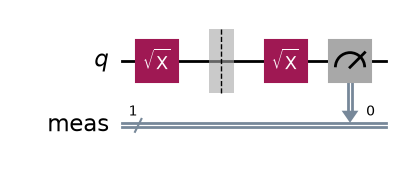

In [3]:
def build_circuit(name, sequence):
    qubits = QuantumRegister(1, name="q")
    bits = ClassicalRegister(1, name="meas")
    circuit = QuantumCircuit(qubits, bits, name=name)
    for k, gate in enumerate(sequence):
        if k > 0:
            circuit.barrier()
        getattr(circuit, gate)(qubits[0])
    circuit.measure(qubits, bits)
    return circuit


circuits = {
    "H": build_circuit("H", ["h"]),
    "SX": build_circuit("SX", ["sx"]),
    "H H": build_circuit("H H", ["h", "h"]),
    "SX SX": build_circuit("SX SX", ["sx", "sx"]),
}
circuits["SX SX"].draw("mpl")

In [4]:
from qiskit.quantum_info import Statevector

print("Ideal amplitudes of |0>, |1> and P(0):")
for name, circuit in circuits.items():
    state = Statevector(circuit.remove_final_measurements(inplace=False))
    print(f"  {name:6s} {state.data}   P(0) = {state.probabilities()[0]:.3f}")

Ideal amplitudes of |0>, |1> and P(0):
  H      [0.707+0.j 0.707+0.j]   P(0) = 0.500
  SX     [0.5+0.5j 0.5-0.5j]   P(0) = 0.500
  H H    [1.+0.j 0.+0.j]   P(0) = 1.000
  SX SX  [0.+0.j 1.+0.j]   P(0) = 0.000


## Step 2: Transpile

The pass manager knows each backend's native gates and layout. On IBM hardware, H becomes `rz`, `sx`, `rz`.

In [5]:
isa_circuits = {}
for target in targets:
    pass_manager = generate_preset_pass_manager(backend=target.backend, optimization_level=1)
    isa_circuits[target.label] = {n: pass_manager.run(c) for n, c in circuits.items()}
    print(target.label)
    for name, isa in isa_circuits[target.label].items():
        print(f"  {name:6s} {dict(isa.count_ops())}")

aer
  H      {'h': 1, 'measure': 1}
  SX     {'sx': 1, 'measure': 1}
  H H    {'h': 2, 'barrier': 1, 'measure': 1}
  SX SX  {'sx': 2, 'barrier': 1, 'measure': 1}


## Step 3: Observable

Not needed. A Sampler has no observable; it just returns bitstrings.

## Step 4: PUBs

A PUB is a tuple that starts with the circuit. Ours have no parameters, so each tuple holds only the circuit. One job can carry many PUBs.

In [6]:
pubs = {label: [(isa,) for isa in group.values()] for label, group in isa_circuits.items()}
print({label: len(p) for label, p in pubs.items()}, "PUBs per target")

{'aer': 4} PUBs per target


## Step 5: Execute

`sampler.run` returns a job. `target.wait` returns its result (on hardware it saves the job ID and waits in the queue).

In [7]:
results = {}
for target in targets:
    job = target.sampler.run(pubs[target.label], shots=SETTINGS.shots)
    results[target.label] = target.wait(job)

## Step 6: Read the results

`result[i]` belongs to `pubs[i]`. `.data.meas` is the classical register we named "meas", and `get_counts()` turns raw shots into `{bitstring: count}`.

In [8]:
for label, result in results.items():
    if result is None:
        continue
    print(f"Counts from {SETTINGS.shots} shots on {label}:")
    for name, pub_result in zip(circuits, result):
        counts = pub_result.data.meas.get_counts()
        p0 = counts.get("0", 0) / SETTINGS.shots
        print(f"  {name:6s} {counts}   P(0) = {p0:.3f}")

Counts from 4096 shots on aer:
  H      {'1': 1957, '0': 2139}   P(0) = 0.522
  SX     {'1': 2045, '0': 2051}   P(0) = 0.501
  H H    {'0': 4096}   P(0) = 1.000
  SX SX  {'1': 4096}   P(0) = 0.000


## Takeaway

`H` and `SX` both give about 50/50, but `H H` returns to 0 and `SX SX` flips to 1. The gates differ in phase, which a single Z measurement cannot see.